<a href="https://colab.research.google.com/github/dwin05/AI-Skin-Diagnosis/blob/Quynh/Skin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#thu vien tensorflow

!pip install -q tensorflow tensorflow-addons

ERROR: Could not find a version that satisfies the requirement tensorflow-addons (from versions: none)
ERROR: No matching distribution found for tensorflow-addons


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [ ]:
# duong dan anh
#!unzip "/content/drive/MyDrive/MachineLearning/SkinDataset.zip" -d "/content/drive/MyDrive/MachineLearning/"
train_dir = "/content/drive/MyDrive/MachineLearning/SkinDataset/train"
test_dir = "/content/drive/MyDrive/MachineLearning/SkinDataset/test"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [ ]:
#load dataset

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='binary',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='binary',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_dataset.class_names
print("Classes:", class_names)

Found 2637 files belonging to 2 classes.
Found 660 files belonging to 2 classes.
Classes: ['benign', 'malignant']


In [ ]:
#toi uu dataset

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

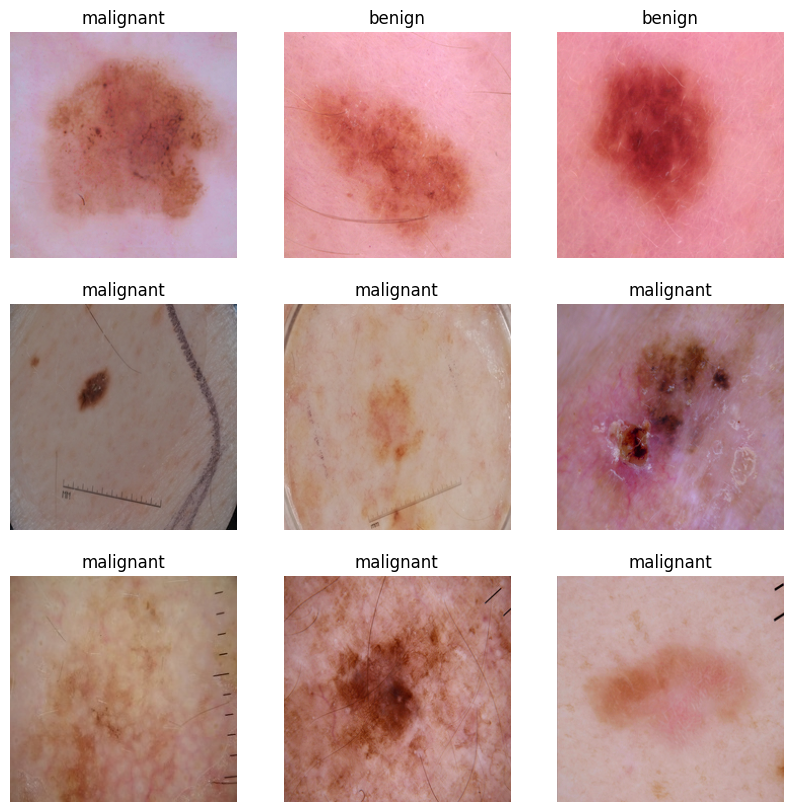

In [ ]:
#hien thi 1 vai anh

plt.figure(figsize=(10,10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")

In [ ]:
data_augmentation = Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2)
])

In [ ]:
# mô hinh EfficientNetV2B0

base_model = tf.keras.applications.EfficientNetV2B0(
    include_top=False,
    weights='imagenet',
    input_shape=(224,224,3)
)

# Khóa trọng số pretrained
base_model.trainable = False

# Tiền xử lý ảnh
preprocess_input = tf.keras.applications.efficientnet_v2.preprocess_input

model = Sequential([

    layers.Input(shape=(224,224,3)),

    data_augmentation,

    layers.Lambda(preprocess_input),

    base_model,

    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(1, activation='sigmoid')

])

model.summary()

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,091,601 (23.24 MB)

 Trainable params: 172,289 (673.00 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# call
save_path = "/content/drive/MyDrive/MachineLearning/best_skin_model.keras"

checkpoint = ModelCheckpoint(
    save_path,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

In [ ]:
#train model
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=20,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6277 - loss: 0.6469
Epoch 1: val_accuracy improved from None to 0.80303, saving model to /content/drive/MyDrive/MachineLearning/best_skin_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/MachineLearning/best_skin_model.keras
83/83 ━━━━━━━━━━━━━━━━━━━━ 341s 4s/step - accuracy: 0.7012 - loss: 0.5648 - val_accuracy: 0.8030 - val_loss: 0.4250
Epoch 2/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7879 - loss: 0.4496
Epoch 2: val_accuracy improved from 0.80303 to 0.81515, saving model to /content/drive/MyDrive/MachineLearning/best_skin_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/MachineLearning/best_skin_model.keras
83/83 ━━━━━━━━━━━━━━━━━━━━ 230s 3s/step - accuracy: 0.7983 - loss: 0.4395 - val_accuracy: 0.8152 - val_loss: 0.3747
Epoch 3/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8070 - loss: 0.4241
Epoch 3: val_accuracy improved from 0.81515 to 0.81970, saving m

In [ ]:
#test
loss, accuracy = model.evaluate(test_dataset)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

21/21 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.8455 - loss: 0.3558
Test Loss: 0.35580974817276
Test Accuracy: 0.8454545736312866


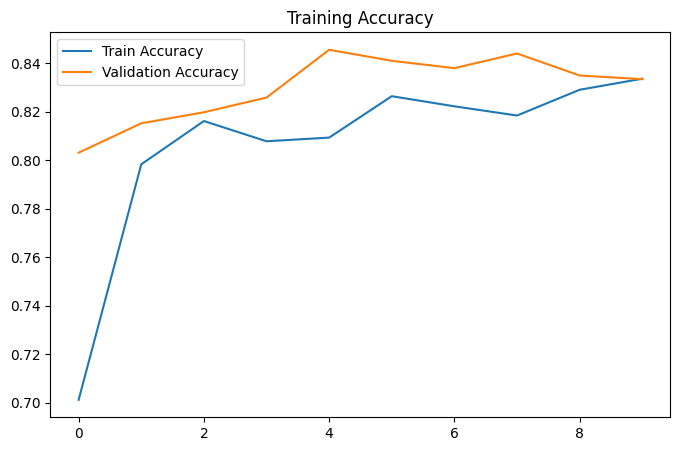

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.figure(figsize=(8,5))

plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')

plt.legend()
plt.title("Training Accuracy")
plt.show()

In [ ]:
best_model = tf.keras.models.load_model(
    save_path,
    custom_objects={'preprocess_input': tf.keras.applications.efficientnet_v2.preprocess_input}
)

In [ ]:
# convert sang tensorflow
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)

tflite_model = converter.convert()

tflite_save_path = "/content/drive/MyDrive/MachineLearning/skin_disease_model.tflite"

with open(tflite_save_path, "wb") as f:
    f.write(tflite_model)

print("Đã lưu TensorFlow Lite model tại:")
print(tflite_save_path)

Saved artifact at '/tmp/tmph7z8mwi5'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  136109935602448: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  136109935602256: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  136109935592272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136109935601296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136109935602832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136109935603600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136109935604176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136109935601680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136109935602640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136109935603984: TensorSpec(shape=(), dtype=tf.resource, name=Non

In [ ]:
from tensorflow.keras.preprocessing import image
import os
import random # For picking a random image
import numpy as np # Add this line to import numpy

# Base directory for test images
base_test_dir = "/content/drive/MyDrive/MachineLearning/SkinDataset/test"

# Define the subdirectories where images are actually located
benign_dir = os.path.join(base_test_dir, "benign")
malignant_dir = os.path.join(base_test_dir, "malignant")

# Choose which directory to pick an image from (e.g., benign)
# You can change 'benign_dir' to 'malignant_dir' to test a malignant image
target_subdir = malignant_dir

# List all files in the target subdirectory
try:
    files_in_subdir = os.listdir(target_subdir)
    # Filter for actual image files (case-insensitive for common image extensions)
    image_files = [f for f in files_in_subdir if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]

    if image_files:
        # Pick a random image from the found images
        selected_image_filename = random.choice(image_files)
        img_path = os.path.join(target_subdir, selected_image_filename)
        print(f"Using image for prediction: {img_path}")
    else:
        raise FileNotFoundError(f"No image files found in {target_subdir}. Please check the directory content.")
except FileNotFoundError as e:
    print(f"Error: {e}")
    print(f"Please ensure the directory '{target_subdir}' exists and contains image files.")
    raise # Re-raise the exception if no images are found or directory doesn't exist
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    raise


img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

prediction = best_model.predict(img_array)

probability = prediction[0][0] * 100

print(f"Confidence of Malignant: {probability:.2f}%")

if prediction[0][0] > 0.5:
    print("Malignant")
else:
    print("Benign")

Using image for prediction: /content/drive/MyDrive/MachineLearning/SkinDataset/test/malignant/797.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Confidence of Malignant: 96.45%
Malignant
